In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [102]:
df = pd.read_csv('heart_disease_prediction.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [103]:
#checking null
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [104]:
df['Sex'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [105]:
gender_id = {
    'M': 0,
    'F':1
}
df['GenderId'] = df['Sex'].map(gender_id)

In [106]:
df['ChestPainType'].unique()

<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

In [107]:
cpt_id = {
    'ATA':0,
    'NAP':1,
    'ASY':2,
    'TA':3
}
df['ChestPainType_id'] = df['ChestPainType'].map(cpt_id)


In [108]:
df['RestingECG'].unique()

<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

In [109]:
re_id = {
    'Normal': 0,
    'ST': 1,
    'LVH': 2
}
df['RestingECG_id'] = df['RestingECG'].map(re_id)

In [110]:
df['ExerciseAngina'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

In [111]:
ea_id = {'N': 0, 'Y': 1}
df['ExerciseAngina'] = df['ExerciseAngina'].map(ea_id)
df['ST_Slope'].unique()
ss_id = {'Up': 0, 'Flat': 1, 'Down': 2}
df['ST_Slope'] = df['ST_Slope'].map(ss_id)

In [112]:
# df['ST_Slope'].unique()

In [113]:
# ss_id = {
#     'Up': 0, 'Flat': 1, 'Down': 2
#     }
# df['ST_Slope'] = df['ST_Slope'].map(ss_id)

In [114]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease', 'GenderId', 'ChestPainType_id', 'RestingECG_id'],
      dtype='str')

In [115]:
features= ['Age', 'ChestPainType_id', 'RestingBP', 'Cholesterol', 'FastingBS',
       'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope','GenderId', 'RestingECG_id']
target= 'HeartDisease'

In [116]:
X = df[features]
Y = df[target]

In [117]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size= 0.2, random_state=42, stratify=Y
)

In [118]:
#feature scaling
scaler= StandardScaler()
X_train_scale = scaler.fit_transform=(X_train)
X_test_scale = scaler.transform=(X_test)

In [119]:
#model training,fitting data and predict

model = LogisticRegression(
     class_weight='balanced', solver='liblinear',random_state=42
)
model.fit(X_train_scale,Y_train)
Y_pred = model.predict(X_test_scale)

In [120]:
#metrices
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)
print(cm)


[[70 12]
 [11 91]]


In [121]:
print(cr)

              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184



<Axes: >

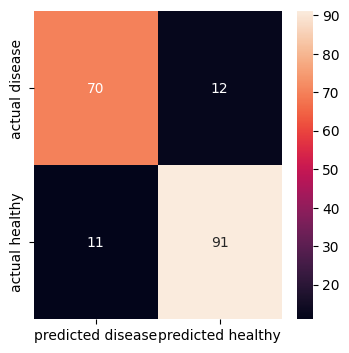

In [122]:
#heat map->correlation
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot= True, xticklabels=['predicted disease','predicted healthy'], yticklabels=['actual disease','actual healthy'])

In [123]:
#KNN -> k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier


In [129]:
error_rate = []
k_range = range(1,21)
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale,  Y_train)
    knn_pred = knn.predict(X_test_scale)
    error_rate.append(np.mean(Y_test !=knn_pred))

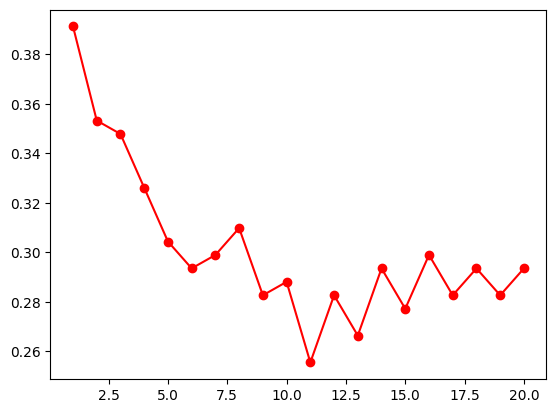

In [130]:
plt.plot(k_range, error_rate , c='red', marker='o')

In [131]:
k_model = KNeighborsClassifier(n_neighbors=7)
k_model.fit(X_train_scale,Y_train)
k_pred = k_model.predict(X_test_scale)

In [132]:
k_cr = classification_report(Y_test,k_pred)
k_cm = confusion_matrix(Y_test,k_pred)
print(k_cm)

[[52 30]
 [25 77]]


In [133]:
print(k_cr)

              precision    recall  f1-score   support

           0       0.68      0.63      0.65        82
           1       0.72      0.75      0.74       102

    accuracy                           0.70       184
   macro avg       0.70      0.69      0.70       184
weighted avg       0.70      0.70      0.70       184

